### Krylov Quantum Diagonalization (KQD)

In [51]:
import numpy as np
import matplotlib.pylab as plt
import warnings

from sympy import Matrix
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from common.krylov_regularized_eigenvalues import single_particle_gs, solve_generalized_eig, \
    solve_generalized_eig_multi
from common.hamiltonians import get_heisenberg_hamiltonian_restricted_to_single_particle_states, \
    build_heisenberg_chain_hamiltonian
from common.time_evolution_circuit import build_efficient_time_evolution_circuit, strip_barriers, \
    build_efficient_time_evolution_circuit_multi, build_multi_ref_circuits
from common.states import get_krylov_initial_state, get_ref_bitstring
from common.krylov_hadamard_test import get_parameters_for_template_circuit, build_modified_hadamard_test_circuit, \
    get_observables_S, get_observables_H, get_expectation_values_S, get_expectation_values_H
from common.expectations_processing import assemble_S_matrix, assemble_H_matrix, assemble_H_and_S_multiref, flat

warnings.filterwarnings("ignore")

### 1: Map problem to quantum circuits and operators

In [52]:
# Define problem Hamiltonian.
n_qubits = 12
H_op = build_heisenberg_chain_hamiltonian(n_qubits)
H_op

SparsePauliOp(['ZZIIIIIIIIII', 'IZZIIIIIIIII', 'IIZZIIIIIIII', 'IIIZZIIIIIII', 'IIIIZZIIIIII', 'IIIIIZZIIIII', 'IIIIIIZZIIII', 'IIIIIIIZZIII', 'IIIIIIIIZZII', 'IIIIIIIIIZZI', 'IIIIIIIIIIZZ', 'XXIIIIIIIIII', 'IXXIIIIIIIII', 'IIXXIIIIIIII', 'IIIXXIIIIIII', 'IIIIXXIIIIII', 'IIIIIXXIIIII', 'IIIIIIXXIIII', 'IIIIIIIXXIII', 'IIIIIIIIXXII', 'IIIIIIIIIXXI', 'IIIIIIIIIIXX', 'YYIIIIIIIIII', 'IYYIIIIIIIII', 'IIYYIIIIIIII', 'IIIYYIIIIIII', 'IIIIYYIIIIII', 'IIIIIYYIIIII', 'IIIIIIYYIIII', 'IIIIIIIYYIII', 'IIIIIIIIYYII', 'IIIIIIIIIYYI', 'IIIIIIIIIIYY'],
              coeffs=[2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j,
 2.+0.j, 2.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 3.+0.j, 3.+0.j, 3.+0.j, 3.+0.j, 3.+0.j,
 3.+0.j, 3.+0.j, 3.+0.j, 3.+0.j, 3.+0.j, 3.+0.j])

In [53]:
# Get Hamiltonian restricted to single-particle states+ 
# meaning you smaller matrix you can diagonalize exactly as a reference:
#  the Hamiltonian projected onto the single-excitation subspace
single_particle_H = get_heisenberg_hamiltonian_restricted_to_single_particle_states(n_qubits, H_op)

# Set dt according to spectral norm
dt = np.pi / np.linalg.norm(single_particle_H, ord=2)
dt

np.float64(0.14279966607226333)

In [54]:
# Set parameters for quantum Krylov algorithm
krylov_dim = 7  # size of krylov subspace
num_trotter_steps = 6 # number of trotter steps per evolution
dt_circ = dt / num_trotter_steps

In [55]:
# for multi reference case
d_refs = 3
s = krylov_dim - 1

### 2. Optimize circuits and operators for target hardware

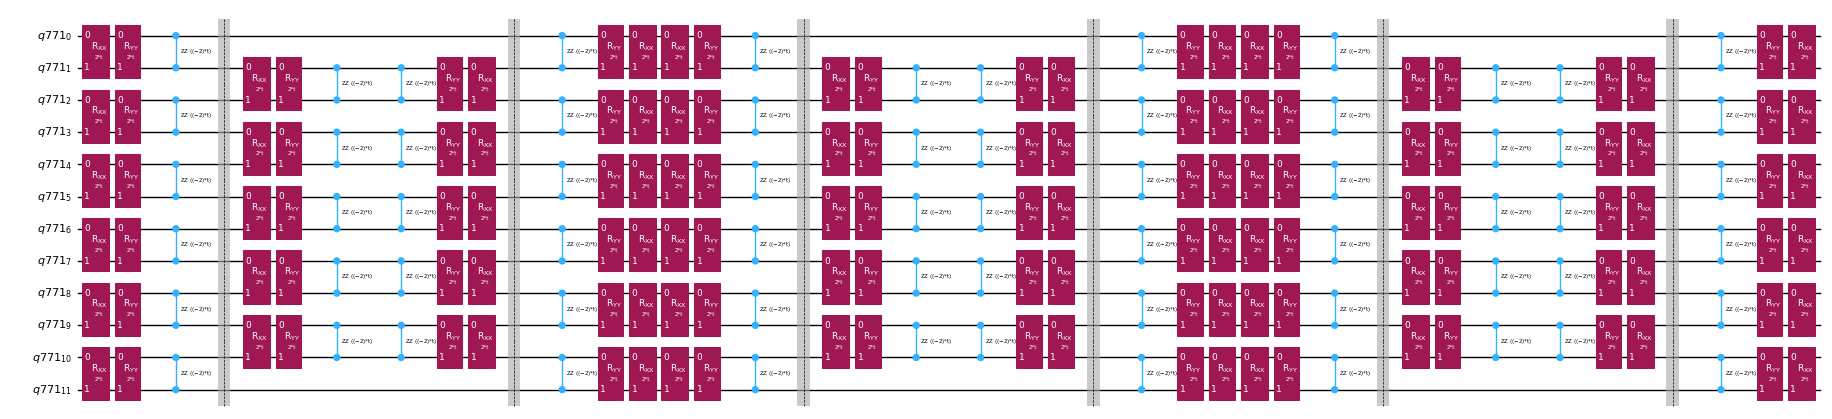

In [56]:
# efficient time evolution block for both sr and mrs case
t = Parameter("t")
qc_evol = build_efficient_time_evolution_circuit(n_qubits, num_trotter_steps, t)
qc_evol.decompose().draw("mpl", fold=-1, scale=0.5)

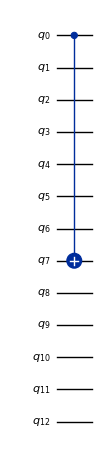

In [57]:
# initial state
controlled_state_prep = get_krylov_initial_state(n_qubits)
controlled_state_prep.draw("mpl", fold=-1, scale=0.5)

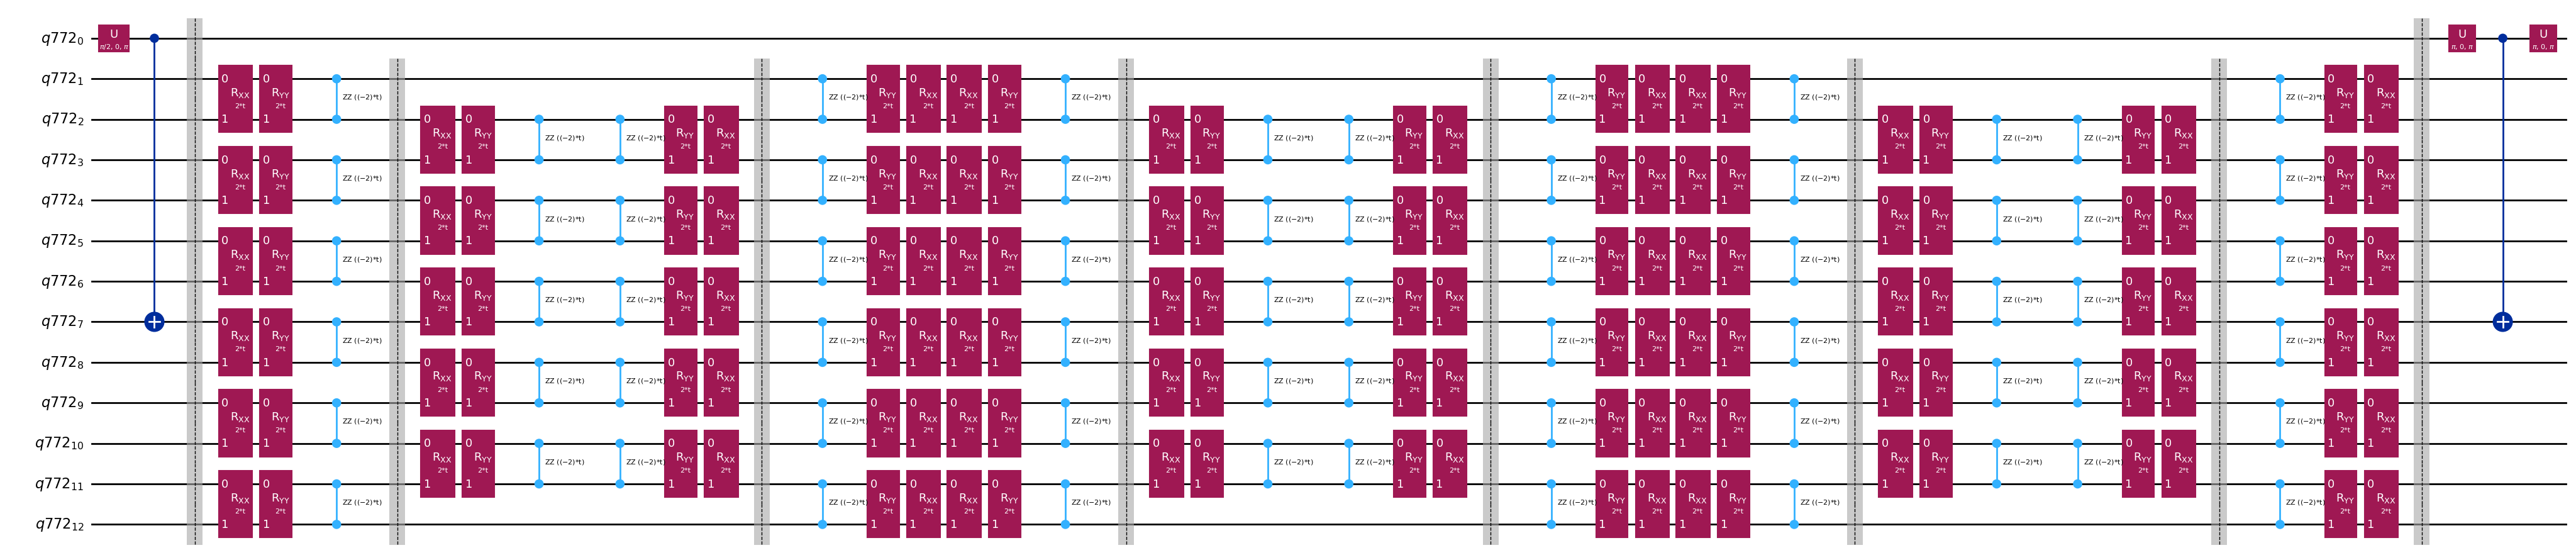

In [58]:
# Hadamard for single ref
parameters = get_parameters_for_template_circuit(krylov_dim, dt_circ)

qc_sr_template = build_modified_hadamard_test_circuit(n_qubits, controlled_state_prep, qc_evol)
qc_sr_template.decompose().draw("mpl", fold=-1)

### 3. Execute using a Qiskit Runtime primitive

In [59]:
backend = AerSimulator()
pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    basis_gates=list(backend.target.operation_names),
)

In [60]:
#the SINGLE-REFERENCE circuit transpile
qc_sr_trans = pm.run(qc_sr_template)
print("SR 2Q depth:", qc_sr_trans.depth(lambda x: x[0].num_qubits == 2))
print("SR ops:", qc_sr_trans.count_ops())

SR 2Q depth: 38
SR ops: OrderedDict({'rxx': 66, 'ryy': 66, 'rzz': 66, 'barrier': 8, 'cx': 2, 'x': 2, 'h': 1})


In [61]:
# S observables: X_anc, Y_anc used for single and reused for multi
observables_S = get_observables_S(n_qubits, qc_sr_trans)

# H observables: for each Pauli term Pk, measure Pk ⊗ X_anc and Pk ⊗ Y_anc
observables_H = get_observables_H(H_op, qc_sr_trans)

print("Total observable groups:", len(observables_S + observables_H))

Total observable groups: 68


### 3.1 Execute for single reference

In [62]:
params = np.vstack(parameters).T   # shape (1, krylov_dim-1) but Estimator treats as P points

# Estimate the expectation value for all combinations of
# observables and parameter values, where the pub result will have
# shape (# observables, # parameter values).
pub_sr = (qc_sr_trans, observables_S + observables_H, params)

estimator = AerEstimator()
job_sr = estimator.run([pub_sr], precision=0.0)
results_sr = job_sr.result()[0]

In [63]:
qc_cliff = qc_sr_template.assign_parameters({t: 0})

# Get expectation values
S_expval = get_expectation_values_S(n_qubits, qc_cliff)
print("S_expval(t=0) =", S_expval)

H_expval = get_expectation_values_H(H_op, qc_cliff)
print("H_expval(t=0) =", H_expval)

S_expval(t=0) = (1+0j)
H_expval(t=0) = (14+0j)


### 3.2 Execute for multiple references

In [64]:
# Create orthogonal reference states
ref_bitstrings = []
for d_ref in range(d_refs):
    ref_bitstrings.append(get_ref_bitstring(d_ref, n_qubits))

print("MR refs:", ref_bitstrings)
print("MR dimension N =", d_refs*(s+1))

MR refs: ['000000100000', '000001000000', '000010000000']
MR dimension N = 21


In [65]:
# MR-only: build a gate-friendly qc_evol_mr with the SAME structure/time parameter t
t = Parameter("t")
qc_evol_mr = build_efficient_time_evolution_circuit_multi(n_qubits, num_trotter_steps, t)

qc_evol_mr_nb = strip_barriers(qc_evol_mr)

In [66]:
circuits_mr, meta_mr = build_multi_ref_circuits(d_refs, s, n_qubits, ref_bitstrings, qc_evol_mr_nb, t, dt_circ)

qc_mr_trans_list = [pm.run(qc) for qc in circuits_mr]

pubs_mr = [(qcT, observables_S + observables_H, None) for qcT in qc_mr_trans_list]
job_mr = estimator.run(pubs_mr, precision=0.0)
results_mr = job_mr.result()

print("MR results entries:", len(results_mr))

MR results entries: 441


### 4. Post-process and analyze results


In [67]:
prefactors = [
    np.exp(-1j * sum([c for p, c in H_op.to_list() if "Z" in p]) * i * dt)
    for i in range(1, krylov_dim)
]

In [68]:
S_sr = assemble_S_matrix(S_expval, results_sr, krylov_dim, prefactors)
Matrix(S_sr)

Matrix([
[                                       1.0,   -0.774072148459425 + 0.497465963327723*I,    0.290909501945608 - 0.637002954732334*I,   0.05607806339674 + 0.390031498069528*I, -0.0483937964756838 - 0.0558494183450929*I,  -0.181086423371468 - 0.0531717714133168*I,   0.328649385251264 - 0.0965001663976781*I],
[  -0.774072148459425 - 0.497465963327723*I,                                        1.0,   -0.774072148459425 + 0.497465963327723*I,  0.290909501945608 - 0.637002954732334*I,     0.05607806339674 + 0.390031498069528*I, -0.0483937964756838 - 0.0558494183450929*I,  -0.181086423371468 - 0.0531717714133168*I],
[   0.290909501945608 + 0.637002954732334*I,   -0.774072148459425 - 0.497465963327723*I,                                        1.0, -0.774072148459425 + 0.497465963327723*I,    0.290909501945608 - 0.637002954732334*I,     0.05607806339674 + 0.390031498069528*I, -0.0483937964756838 - 0.0558494183450929*I],
[    0.05607806339674 - 0.390031498069528*I,    0.290909501945608 +

In [69]:
H_sr = assemble_H_matrix(H_expval, H_op, results_sr, krylov_dim, prefactors)
Matrix(H_sr)

Matrix([
[                                   14.0, -9.65188581591313 + 8.80861283481754*I, 0.562760291088195 - 10.5209922049112*I,  5.35691655426024 + 4.80311196572858*I, -3.95604968948036 + 2.05897622557957*I, -1.64533517296727 - 3.77503989448841*I, 5.00928857158714 + 0.0391895907342448*I],
[ -9.65188581591313 - 8.80861283481754*I,                                   14.0, -9.65188581591313 + 8.80861283481754*I, 0.562760291088195 - 10.5209922049112*I,  5.35691655426024 + 4.80311196572858*I, -3.95604968948036 + 2.05897622557957*I,  -1.64533517296727 - 3.77503989448841*I],
[ 0.562760291088195 + 10.5209922049112*I, -9.65188581591313 - 8.80861283481754*I,                                   14.0, -9.65188581591313 + 8.80861283481754*I, 0.562760291088195 - 10.5209922049112*I,  5.35691655426024 + 4.80311196572858*I,  -3.95604968948036 + 2.05897622557957*I],
[  5.35691655426024 - 4.80311196572858*I, 0.562760291088195 + 10.5209922049112*I, -9.65188581591313 - 8.80861283481754*I,                  

In [70]:
# solve generalized eigenvalue problem for sr case
print("Single ref case:")
gnd_sr_list = solve_generalized_eig(H_sr, S_sr, krylov_dim, threshold=1e-6)

Single ref case:
Estimated ground state energy for d=1:  14.0
Estimated ground state energy for d=2:  8.402070354580138
Estimated ground state energy for d=3:  7.159410191864533
Estimated ground state energy for d=4:  6.764322547659397
Estimated ground state energy for d=5:  6.682806049012369
Estimated ground state energy for d=6:  6.678824511091899
Estimated ground state energy for d=7:  6.674126861534851


In [71]:
# for MULTIREFERENCE extract for full H and S matrix
S_mr, H_mr = assemble_H_and_S_multiref(d_refs, s, meta_mr, results_mr, H_op)

evals = np.linalg.eigvalsh(S_mr)
print("MR S eig min/max:", evals.min(), evals.max())
print("MR diag(S) min/max:", np.real(np.diag(S_mr)).min(), np.real(np.diag(S_mr)).max())

MR S eig min/max: -2.363450671281484e-15 6.712325362701128
MR diag(S) min/max: 0.9999999999999769 1.0000000000000169


In [72]:
print("Multireference case")

gnd_mr_list = solve_generalized_eig_multi(S_mr, H_mr, krylov_dim, s, d_refs)

Multireference case
Estimated ground energy (k=1, dim=3): 8.34314575050762
Estimated ground energy (k=2, dim=6): 6.620297564129872
Estimated ground energy (k=3, dim=9): 6.622878171865503
Estimated ground energy (k=4, dim=12): 6.414068452471144
Estimated ground energy (k=5, dim=15): 6.426303850425349
Estimated ground energy (k=6, dim=18): 6.319145353546578
Estimated ground energy (k=7, dim=21): 6.272593389723662


In [73]:
print("Diag(S_mr) first 10:", np.real(np.diag(S_mr))[:10])
print("||S - S†||:", np.linalg.norm(S_mr - S_mr.conj().T))
print("||H - H†||:", np.linalg.norm(H_mr - H_mr.conj().T))
I = 1
print("S(I=1,n=0 vs n=1):", S_mr[flat(I,0,s), flat(I,1,s)])
print("S(I=1,n=0 vs n=2):", S_mr[flat(I,0,s), flat(I,2,s)])

Diag(S_mr) first 10: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
||S - S†||: 0.0
||H - H†||: 0.0
S(I=1,n=0 vs n=1): (0.4974659633277182+0.7740721484594162j)
S(I=1,n=0 vs n=2): (-0.29090950194560783+0.6370029547323347j)


In [74]:
gs_en = single_particle_gs(H_op, n_qubits)
print("Exact single-particle GS energy:", gs_en)

n_sys_qubits 12
n_exc 1 , subspace dimension 13
single particle ground state energy:  6.272593389687452
Exact single-particle GS energy: 6.272593389687452


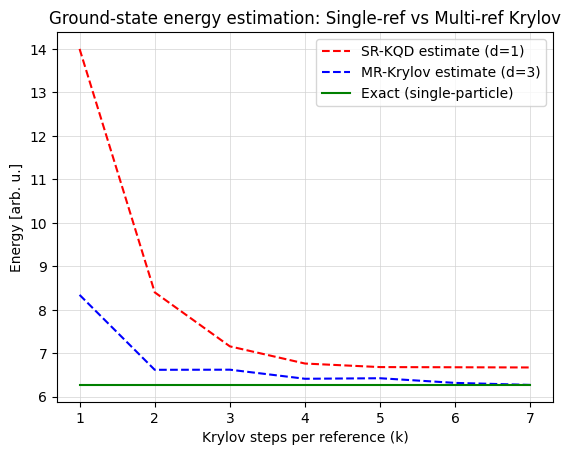

In [75]:
plt.grid(True, which='both', color='lightgray', linestyle='-', linewidth=0.5, alpha=1)
plt.plot(
    range(1, krylov_dim + 1),
    gnd_sr_list,
    color="red",
    linestyle="--",
    label="SR-KQD estimate (d=1)",
)
plt.plot(
    range(1, krylov_dim + 1),
    gnd_mr_list,
    color="blue",
    linestyle="--",
    label="MR-Krylov estimate (d=3)",
)
plt.plot(
    range(1, krylov_dim + 1),
    [gs_en] * krylov_dim,
    color="green",
    linestyle="-",
    label="Exact (single-particle)",
)

plt.xticks(range(1, krylov_dim + 1), range(1, krylov_dim + 1))
plt.legend()
plt.xlabel("Krylov steps per reference (k)")
plt.ylabel("Energy [arb. u.]")
plt.title("Ground-state energy estimation: Single-ref vs Multi-ref Krylov")
plt.show()